In [37]:
!ls

"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [38]:
import pandas as pd

In [ ]:
df_scores = pd.read_csv('RESULTADOSBD3/resultados_combinados.csv', header=None, names=['nombre_imagen_1', 'nombre_imagen_2', 'score', 'tiempo'])
df_scores.head(10)

# tener en cuenta que en la BD3 hay imagenes que no siguen el formato de las transformaciones, p.e., "img184_jpeg.rf.4a8e769d1ad399fb673b62bdfc90112d_150_114"

,nombre_imagen_1,nombre_imagen_2,score,tiempo
0,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,cody-black-bL5j2vSSLA8-unsplash_JPG.rf.36b3bb5...,0.006718,804.700
1,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2500_jpg.rf.f94d6b7d5289db88fcace4a185838c...,0.005406,769.142
2,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG-20170415-WA0017_jpg.rf.50ab4e6dd8799bcc415...,0.004941,679.452
3,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,1.000000,169.738
4,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_20160331_145211_jpg.rf.2f3bf894601ebf80974...,0.006296,645.584
5,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2648_jpg.rf.6ea5ead075cc32eccec39f7c370c1b...,0.004758,689.421
6,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG-20160310-WA0007_jpg.rf.541924b73f7a5b2f100...,0.005635,681.789
7,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2613_jpg.rf.b0362edfc43d6506c7e4214450af3b...,0.004616,704.757
8,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-20-at-19-08-20-4-_jpeg....,0.006053,693.424
9,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-20-at-19-08-19_jpeg.rf....,0.004787,730.750


In [ ]:
df_labels = pd.read_csv('RESULTADOSBD3/ETIQUETASBD3FINAL.csv')

# Remove the file extensions
df_labels['nombre_imagen'] = df_labels['nombre_imagen'].str.rsplit('.', n=1).str[0]

print("DataFrame 2 (df_individuos) después de la estandarización:")
df_labels.head(10)

DataFrame 2 (df_individuos) después de la estandarización:


,nombre_imagen,id_individuo
0,11866244_10153203202012872_8603664593573432067...,1
1,1427598107355_jpg.rf.aea38ce544f6e68e713377410...,2
2,19de3f3a6ce352053c7f02bf8a4dad4b_jpg.rf.975608...,3
3,20180129_172446_jpg.rf.3e0ff84281b07c0d264e2a6...,4
4,20180204_191140_jpg.rf.4bff4f7362b47099d965d8f...,5
5,20180207_182930_jpg.rf.dbc8bae232d1e976cbbbbde...,6
6,20180212_003230_jpg.rf.c3536084e7fd20e1b2fa2b2...,7
7,20180226_121540_jpg.rf.a3bceda0aa1c25acb0dd4fc...,8
8,20180403_131545_jpg.rf.71178d4ee38bc112b7901d1...,9
9,20180408_182630_jpg.rf.766b4a8336243d042c0abd1...,10


In [41]:
# Unir df_scores con df_individuos usando 'nombre_imagen_1'
# 'left_on' especifica la columna en el primer DataFrame (df_scores)
# 'right_on' especifica la columna en el segundo DataFrame (df_individuos)
df_merged_1 = pd.merge(df_scores, df_labels, left_on='nombre_imagen_1', right_on='nombre_imagen', how='left')

# Renombrar la nueva columna para que sea id_individuo_1
df_merged_1.rename(columns={'id_individuo': 'id_individuo_1'}, inplace=True)

# Eliminar la columna 'nombre_imagen' que ya no es necesaria
df_merged_1.drop('nombre_imagen', axis=1, inplace=True)

print("\nDataFrame intermedio después de la primera unión:")
df_merged_1.head(10)


DataFrame intermedio después de la primera unión:


,nombre_imagen_1,nombre_imagen_2,score,tiempo,id_individuo_1
0,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,cody-black-bL5j2vSSLA8-unsplash_JPG.rf.36b3bb5...,0.006718,804.700,545
1,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2500_jpg.rf.f94d6b7d5289db88fcace4a185838c...,0.005406,769.142,545
2,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG-20170415-WA0017_jpg.rf.50ab4e6dd8799bcc415...,0.004941,679.452,545
3,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,1.000000,169.738,545
4,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_20160331_145211_jpg.rf.2f3bf894601ebf80974...,0.006296,645.584,545
5,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2648_jpg.rf.6ea5ead075cc32eccec39f7c370c1b...,0.004758,689.421,545
6,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG-20160310-WA0007_jpg.rf.541924b73f7a5b2f100...,0.005635,681.789,545
7,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2613_jpg.rf.b0362edfc43d6506c7e4214450af3b...,0.004616,704.757,545
8,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-20-at-19-08-20-4-_jpeg....,0.006053,693.424,545
9,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-20-at-19-08-19_jpeg.rf....,0.004787,730.750,545


In [42]:
# Unir el DataFrame intermedio con df_individuos usando 'nombre_imagen_2'
df_final = pd.merge(df_merged_1, df_labels, left_on='nombre_imagen_2', right_on='nombre_imagen', how='left')

# Renombrar la nueva columna
df_final.rename(columns={'id_individuo': 'id_individuo_2'}, inplace=True)

# Eliminar la columna 'nombre_imagen' sobrante
df_final.drop('nombre_imagen', axis=1, inplace=True)

print("\nDataFrame Final:")
df_final.head(10)


DataFrame Final:


,nombre_imagen_1,nombre_imagen_2,score,tiempo,id_individuo_1,id_individuo_2
0,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,cody-black-bL5j2vSSLA8-unsplash_JPG.rf.36b3bb5...,0.006718,804.700,545,47
1,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2500_jpg.rf.f94d6b7d5289db88fcace4a185838c...,0.005406,769.142,545,169
2,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG-20170415-WA0017_jpg.rf.50ab4e6dd8799bcc415...,0.004941,679.452,545,82
3,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,1.000000,169.738,545,545
4,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_20160331_145211_jpg.rf.2f3bf894601ebf80974...,0.006296,645.584,545,106
5,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2648_jpg.rf.6ea5ead075cc32eccec39f7c370c1b...,0.004758,689.421,545,283
6,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG-20160310-WA0007_jpg.rf.541924b73f7a5b2f100...,0.005635,681.789,545,64
7,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2613_jpg.rf.b0362edfc43d6506c7e4214450af3b...,0.004616,704.757,545,239
8,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-20-at-19-08-20-4-_jpeg....,0.006053,693.424,545,447
9,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-20-at-19-08-19_jpeg.rf....,0.004787,730.750,545,443


In [43]:
df_final.drop('tiempo', axis=1, inplace=True)

df_sin_round = df_final

df_final['score'] = df_final['score'].round(5)
df_final.head(10)

,nombre_imagen_1,nombre_imagen_2,score,id_individuo_1,id_individuo_2
0,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,cody-black-bL5j2vSSLA8-unsplash_JPG.rf.36b3bb5...,0.00672,545,47
1,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2500_jpg.rf.f94d6b7d5289db88fcace4a185838c...,0.00541,545,169
2,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG-20170415-WA0017_jpg.rf.50ab4e6dd8799bcc415...,0.00494,545,82
3,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,1.00000,545,545
4,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_20160331_145211_jpg.rf.2f3bf894601ebf80974...,0.00630,545,106
5,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2648_jpg.rf.6ea5ead075cc32eccec39f7c370c1b...,0.00476,545,283
6,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG-20160310-WA0007_jpg.rf.541924b73f7a5b2f100...,0.00563,545,64
7,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2613_jpg.rf.b0362edfc43d6506c7e4214450af3b...,0.00462,545,239
8,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-20-at-19-08-20-4-_jpeg....,0.00605,545,447
9,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-20-at-19-08-19_jpeg.rf....,0.00479,545,443


In [44]:
mascara = (df_final['id_individuo_1'] == None) | (df_final['id_individuo_2'] == None)
df_final[mascara].head()

,nombre_imagen_1,nombre_imagen_2,score,id_individuo_1,id_individuo_2


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(plt.style.available)
plt.style.use('seaborn-paper')

['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn', 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark', 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep', 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper', 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk', 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid', 'tableau-colorblind10']


In [46]:
# Clasificar cada fila
df_final['tipo_coincidencia'] = df_final.apply(
    lambda row: 'Genuina' if row['id_individuo_1'] == row['id_individuo_2'] else 'Impostora',
    axis=1
)
df_final.head(10)

,nombre_imagen_1,nombre_imagen_2,score,id_individuo_1,id_individuo_2,tipo_coincidencia
0,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,cody-black-bL5j2vSSLA8-unsplash_JPG.rf.36b3bb5...,0.00672,545,47,Impostora
1,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2500_jpg.rf.f94d6b7d5289db88fcace4a185838c...,0.00541,545,169,Impostora
2,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG-20170415-WA0017_jpg.rf.50ab4e6dd8799bcc415...,0.00494,545,82,Impostora
3,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,1.00000,545,545,Genuina
4,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_20160331_145211_jpg.rf.2f3bf894601ebf80974...,0.00630,545,106,Impostora
5,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2648_jpg.rf.6ea5ead075cc32eccec39f7c370c1b...,0.00476,545,283,Impostora
6,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG-20160310-WA0007_jpg.rf.541924b73f7a5b2f100...,0.00563,545,64,Impostora
7,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,IMG_2613_jpg.rf.b0362edfc43d6506c7e4214450af3b...,0.00462,545,239,Impostora
8,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-20-at-19-08-20-4-_jpeg....,0.00605,545,447,Impostora
9,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....,WhatsApp-Image-2022-11-20-at-19-08-19_jpeg.rf....,0.00479,545,443,Impostora


In [47]:
import numpy as np
from sklearn.metrics import roc_curve

# Suponiendo que 'df_final' tiene las columnas 'score' y 'tipo_coincidencia'

# 1. Definir las etiquetas y los scores
y_true = (df_final['tipo_coincidencia'] == 'Genuina').astype(int)
y_scores = df_final['score']

# 2. Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# 3. Calcular la Tasa de Falsos Negativos (FNR)
fnr = 1 - tpr

# 4. Encontrar el índice donde la diferencia entre FPR y FNR es mínima
index_of_eer = np.argmin(np.abs(fpr - fnr))

# 5. Obtener el EER y el umbral correspondiente
eer_threshold = thresholds[index_of_eer]
eer = fpr[index_of_eer] # O fnr[index_of_eer], ya que son casi iguales en este punto

print(f"El Umbral de Similitud Óptimo con el menor EER es: {eer_threshold:.4f}")
print(f"El EER (Tasa de Error) en este umbral es: {eer:.4f}")

El Umbral de Similitud Óptimo con el menor EER es: 0.0110
El EER (Tasa de Error) en este umbral es: 0.0183


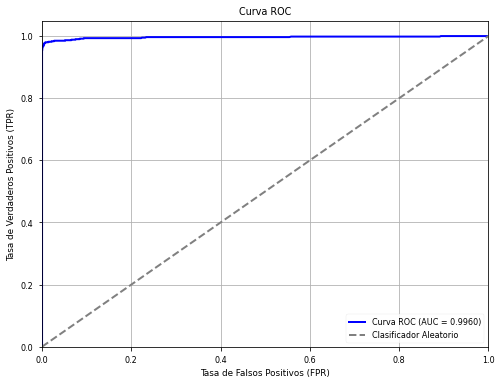

El Área Bajo la Curva (AUC) es: 0.9960


In [48]:
from sklearn.metrics import roc_auc_score

# 2. Calcular el AUC
auc = roc_auc_score(y_true, y_scores)

# 3. Graficar la Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"El Área Bajo la Curva (AUC) es: {auc:.4f}")

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Suponiendo que 'df_final' y 'tipo_coincidencia' ya están definidos
# y_scores_genuine y y_scores_imposter son los arrays de scores
y_scores_genuine = df_final[df_final['tipo_coincidencia'] == 'Genuina']['score'].values
y_scores_imposter = df_final[df_final['tipo_coincidencia'] == 'Impostora']['score'].values

# Crear un rango de puntos para evaluar la densidad
x_range = np.linspace(min(df_final['score']), max(df_final['score']), 1000)

# Calcular las densidades de probabilidad
kde_genuine = gaussian_kde(y_scores_genuine)
density_genuine = kde_genuine(x_range)

kde_imposter = gaussian_kde(y_scores_imposter)
density_imposter = kde_imposter(x_range)

In [50]:
# Encontrar los valores máximos de densidad
max_density_genuine = density_genuine.max()
max_density_imposter = density_imposter.max()

# Normalizar los valores de densidad a una escala de 0-100
normalized_density_genuine = (density_genuine / max_density_genuine) * 100
normalized_density_imposter = (density_imposter / max_density_imposter) * 100

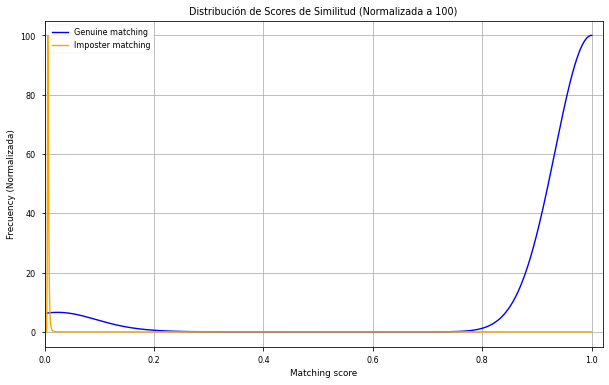

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(x_range, normalized_density_genuine, color='blue', label='Genuine matching')
plt.plot(x_range, normalized_density_imposter, color='orange', label='Imposter matching')

plt.title('Distribución de Scores de Similitud (Normalizada a 100)')
plt.xlabel('Matching score')
plt.ylabel('Frecuency (Normalizada)')
plt.xlim(0, 1.02) # Ajusta este rango según tus datos
plt.legend()
plt.grid(True)
plt.show()

In [68]:
import pandas as pd
import re

# Suponiendo que 'df_final' es tu DataFrame
# y las columnas 'nombre_imagen_1' y 'nombre_imagen_2' tienen el formato "label_number<_transformation>.jpg"

def get_transformation_type(filename):
    """
    Clasifica el tipo de transformación a partir del nombre de archivo.
    """
    # Regex más flexible para capturar el código de transformación
    # Busca un guión bajo seguido de uno de los códigos de transformación
    # y termina con la extensión .jpg o .png (u otra)
    match = re.search(r'_(a[1-4]|ar[1-4]|b[1-2]|c[1-4]|i[1-2]|r[1-4])(\.jpg|\.png)?$', filename)

    if match:
        transformation_code = match.group(1)
        if transformation_code.startswith('a'):
            return 'affine'
        elif transformation_code.startswith('ar'):
            return 'aspect ratio'
        elif transformation_code.startswith('b'):
            return 'blurring'
        elif transformation_code.startswith('c'):
            return 'color'
        elif transformation_code.startswith('i'):
            return 'illumination'
        elif transformation_code.startswith('r'):
            return 'rotation'
    return 'none' # Si no se encuentra un código de transformación válido

# Aplicar la función a las dos columnas de nombres de imagen
df_final['transformacion_1'] = df_final['nombre_imagen_1'].apply(get_transformation_type)
df_final['transformacion_2'] = df_final['nombre_imagen_2'].apply(get_transformation_type)

# Mostrar las nuevas columnas para verificar
print(df_final[['nombre_imagen_1', 'transformacion_1', 'nombre_imagen_2', 'transformacion_2']].head())

                                     nombre_imagen_1 transformacion_1  \
0  WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....             none   
1  WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....             none   
2  WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....             none   
3  WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....             none   
4  WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....             none   

                                     nombre_imagen_2 transformacion_2  
0  cody-black-bL5j2vSSLA8-unsplash_JPG.rf.36b3bb5...             none  
1  IMG_2500_jpg.rf.f94d6b7d5289db88fcace4a185838c...             none  
2  IMG-20170415-WA0017_jpg.rf.50ab4e6dd8799bcc415...             none  
3  WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg....             none  
4  IMG_20160331_145211_jpg.rf.2f3bf894601ebf80974...             none  


In [65]:
import pandas as pd

# Suponiendo que df_final es tu DataFrame con la columna 'transformacion_2'

# 1. Define la lista de todos los tipos de transformación
tipos_transformacion = ['affine', 'aspect ratio', 'blurring', 'color', 'illumination', 'rotation', 'none']

# Diccionarios para almacenar los DataFrames
df_con_transformacion = {}
df_sin_transformacion = {}

# 2. Iterar sobre cada tipo de transformación
for tipo in tipos_transformacion:
    # 3. Crear una máscara para las filas que tienen la transformación
    mascara_con = (df_final['transformacion_1'] == tipo) | (df_final['transformacion_2'] == tipo)

    # 4. Filtrar y almacenar los DataFrames
    df_con = df_final[mascara_con].copy()
    df_sin = df_final[~mascara_con].copy() # El símbolo '~' invierte la máscara

    # Guardar los DataFrames en diccionarios
    df_con_transformacion[tipo] = df_con
    df_sin_transformacion[tipo] = df_sin

# Ejemplo de cómo acceder a los DataFrames resultantes:
print("Número de filas con transformación 'affine':", len(df_con_transformacion['affine']))
print("Número de filas sin transformación 'affine':", len(df_sin_transformacion['affine']))
print("-" * 50)
print("Número de filas con transformación 'color':", len(df_con_transformacion['color']))
print("Número de filas sin transformación 'color':", len(df_sin_transformacion['color']))

Número de filas con transformación 'affine': 0
Número de filas sin transformación 'affine': 314721
--------------------------------------------------
Número de filas con transformación 'color': 0
Número de filas sin transformación 'color': 314721


In [64]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve

def compute_eer(df):
    # Check if the DataFrame is empty or only contains one class
    if df.empty or df['tipo_coincidencia'].nunique() < 2:
        print("  - Datos insuficientes para calcular el EER.")
        print(f"  - Filas: {len(df)}, Tipos de Coincidencia: {df['tipo_coincidencia'].nunique()}")
        return

    # 1. Definir las etiquetas y los scores
    y_true = (df['tipo_coincidencia'] == 'Genuina').astype(int)
    y_scores = df['score']

    # 2. Calcular la curva ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    # 3. Calcular la Tasa de Falsos Negativos (FNR)
    fnr = 1 - tpr

    # 4. Encontrar el índice donde la diferencia entre FPR y FNR es mínima
    index_of_eer = np.argmin(np.abs(fpr - fnr))

    # 5. Obtener el EER y el umbral correspondiente
    eer_threshold = thresholds[index_of_eer]
    eer = fpr[index_of_eer] # O fnr[index_of_eer], ya que son casi iguales en este punto

    print(f"  - Umbral de Similitud Óptimo (EER): {eer_threshold:.4f}")
    print(f"  - EER (Tasa de Error): {eer:.4f}")

# Your code for creating df_final and the filtered dictionaries goes here...

# =================================================================
# Iteración y cálculo
# =================================================================
tipos_transformacion = ['affine', 'aspect ratio', 'blurring', 'color', 'illumination', 'rotation', 'none']

# Diccionarios para almacenar los DataFrames filtrados
df_con_transformacion = {}
df_sin_transformacion = {}
for tipo in tipos_transformacion:
    mascara_con = (df_final['transformacion_1'] == tipo) | (df_final['transformacion_2'] == tipo)
    df_con_transformacion[tipo] = df_final[mascara_con].copy()
    df_sin_transformacion[tipo] = df_final[~mascara_con].copy()


for tipo in tipos_transformacion:
    print("-" * 50)
    print(f"Resultados para la transformación '{tipo}':")
    compute_eer(df_con_transformacion[tipo])

    print(f"\nResultados sin la transformación '{tipo}':")
    compute_eer(df_sin_transformacion[tipo])

--------------------------------------------------
Resultados para la transformación 'affine':
  - Datos insuficientes para calcular el EER.
  - Filas: 0, Tipos de Coincidencia: 0

Resultados sin la transformación 'affine':
  - Umbral de Similitud Óptimo (EER): 0.0110
  - EER (Tasa de Error): 0.0183
--------------------------------------------------
Resultados para la transformación 'aspect ratio':
  - Datos insuficientes para calcular el EER.
  - Filas: 0, Tipos de Coincidencia: 0

Resultados sin la transformación 'aspect ratio':
  - Umbral de Similitud Óptimo (EER): 0.0110
  - EER (Tasa de Error): 0.0183
--------------------------------------------------
Resultados para la transformación 'blurring':
  - Datos insuficientes para calcular el EER.
  - Filas: 0, Tipos de Coincidencia: 0

Resultados sin la transformación 'blurring':
  - Umbral de Similitud Óptimo (EER): 0.0110
  - EER (Tasa de Error): 0.0183
--------------------------------------------------
Resultados para la transformac

In [69]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve

# Suponiendo que df_final es tu DataFrame final y las columnas
# 'id_individuo_1', 'tipo_coincidencia' y 'score' ya están definidas.

def compute_eer(df):
    """
    Calcula el EER y el umbral óptimo para un DataFrame dado.
    """
    # Verificación de datos insuficientes
    if df.empty or df['tipo_coincidencia'].nunique() < 2:
        return None  # Retorna None si no se puede calcular

    y_true = (df['tipo_coincidencia'] == 'Genuina').astype(int)
    y_scores = df['score']

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr

    # Manejar el caso de un solo tipo de coincidencia
    if all(y_true) or not any(y_true):
        return None

    index_of_eer = np.argmin(np.abs(fpr - fnr))
    eer = fpr[index_of_eer]

    return eer

# Diccionario para almacenar los EER de cada individuo
eer_por_individuo = {}

# Agrupar el DataFrame por id_individuo_1
grupos_individuo = df_final.groupby('id_individuo_1')

# Iterar a través de cada grupo y calcular el EER
for id_individuo, grupo_df in grupos_individuo:
    eer = compute_eer(grupo_df)
    if eer is not None:
        eer_por_individuo[id_individuo] = eer

# Ordenar los resultados de mayor a menor EER
resultados_ordenados = sorted(eer_por_individuo.items(), key=lambda item: item[1], reverse=True)

# Imprimir los resultados
print("Resultados de EER por individuo (ordenados de mayor a menor):")
for individuo, eer_val in resultados_ordenados:
    if eer_val > 0.30:
        print(f"Individuo {individuo}: EER = {eer_val:.4f}")

Resultados de EER por individuo (ordenados de mayor a menor):


In [67]:
import numpy as np
from sklearn.metrics import roc_curve

# Suponiendo que 'df_final' ya tiene la columna 'tipo_coincidencia'
y_true = (df_final['tipo_coincidencia'] == 'Genuina').astype(int)
y_scores = df_final['score']

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
fnr = 1 - tpr

# Encontrar el índice donde la diferencia entre FPR y FNR es mínima
index_of_eer = np.argmin(np.abs(fpr - fnr))

eer_threshold = thresholds[index_of_eer]
eer = fpr[index_of_eer]

print(f"El Umbral de Similitud Óptimo con el menor EER es: {eer_threshold:.4f}")
print(f"El EER (Tasa de Error) en este umbral es: {eer:.4f}")

El Umbral de Similitud Óptimo con el menor EER es: 0.0110
El EER (Tasa de Error) en este umbral es: 0.0183


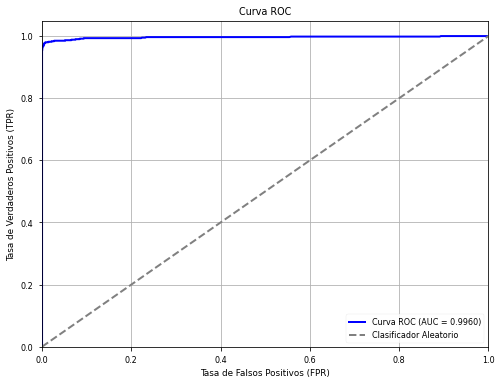

El Área Bajo la Curva (AUC) es: 0.9960


In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Suponiendo que 'df_final' ya tiene la columna 'tipo_coincidencia'
y_true = (df_final['tipo_coincidencia'] == 'Genuina').astype(int)
y_scores = df_final['score']

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc = roc_auc_score(y_true, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"El Área Bajo la Curva (AUC) es: {auc:.4f}")

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import re

# Suponiendo que df_final es tu DataFrame con todas las columnas
# Necesitamos la columna 'id_individuo_2' para la función
df_final['id_individuo_1'] = df_final['nombre_imagen_1'].str.split('_').str[0]
df_final['id_individuo_2'] = df_final['nombre_imagen_2'].str.split('_').str[0]


# --- Código Corregido para preparar la score_matrix ---

# Paso 1: Obtener todos los nombres de imágenes únicos
all_images = pd.concat([
    df_final['nombre_imagen_1'],
    df_final['nombre_imagen_2']
]).unique()

# Paso 2: Crear la tabla pivote de scores
score_matrix_df = df_final.pivot_table(
    index='nombre_imagen_1',
    columns='nombre_imagen_2',
    values='score'
)

# Paso 3: Crear la matriz completa de scores
score_matrix = pd.DataFrame(index=all_images, columns=all_images)
score_matrix.update(score_matrix_df)
score_matrix.update(score_matrix_df.T) # Llenar scores simétricos

# Paso 4: Llenar la diagonal y valores nulos
np.fill_diagonal(score_matrix.values, 1.0)
score_matrix.fillna(0, inplace=True) # Llenar los pares que no están en el DataFrame original con 0

# Crear un mapeo robusto de imagen a ID de individuo
image_to_id = pd.concat([
    df_final[['nombre_imagen_1', 'id_individuo_1']].rename(columns={'nombre_imagen_1': 'imagen', 'id_individuo_1': 'id'}),
    df_final[['nombre_imagen_2', 'id_individuo_2']].rename(columns={'nombre_imagen_2': 'imagen', 'id_individuo_2': 'id'})
]).drop_duplicates().set_index('imagen')['id']

In [59]:
score_matrix.head(10)

,WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg.rf.6d693fbc21165aafab3ea7ad598653ab_590_860,IMG_20160331_145211_jpg.rf.2f3bf894601ebf80974058d282416310_312_125,IMG_2648_jpg.rf.6ea5ead075cc32eccec39f7c370c1b00_39_62,IMG-20160310-WA0007_jpg.rf.541924b73f7a5b2f100df148647e07b1_180_703,IMG_2613_jpg.rf.b0362edfc43d6506c7e4214450af3b55_14_62,WhatsApp-Image-2022-11-20-at-19-08-20-4-_jpeg.rf.ece34c3a7600b41e24953fad05b3b2ae_363_226,WhatsApp-Image-2022-11-20-at-19-08-19_jpeg.rf.5a1dfaa5a9c495315c4518dd5ecba85d_460_515,ivan4_jpg.rf.93aba2068dcfb3dd7d4ae371e76a22e6_81_83,IMG_2690_jpg.rf.1cb182866e1b61ebb34bc954bea802f7_54_33,WhatsApp-Image-2022-11-20-at-19-41-07-6-_jpeg.rf.99f38d9194b3f9bc4cb422900e7a1d76_62_116,...,WhatsApp-Image-2022-11-21-at-14-09-44-1-_jpeg.rf.ed4dec6afba47b0163a0f5ab7dc41e13_65_610,IMG_2688_jpg.rf.b8579c661f13b5d3204562feb1b7417b_132_104,WhatsApp-Image-2022-11-20-at-19-20-23-3-_jpeg.rf.e71dd8f7171b3c138f8fa1bab735d932_30_142,IMG_2470_jpg.rf.01d3e3c394d41c1e93953f1eab7fc7ca_38_65,maxi3_jpg.rf.0dbfff2f15e0fe7ff418e287b3a6d9aa_113_16,ivan1_jpg.rf.69021313663b5218bc5b8e88a6bf9a11_83_103,IMG_4460_jpg.rf.213100592ea786a5d8ac883b82c32af4_32_33,IMG_1007_jpg.rf.3d0b4c56040b03b8683d7bdb2daaec02_773_1140,IMG_2587_jpg.rf.64f51489fecdc0836697e591a2acc218_47_145,IMG_2510_jpg.rf.57c1bdaa39fe9e8398855d4a9a22407c_121_101
WhatsApp-Image-2022-11-21-at-12-08-50-1-_jpeg.rf.6d693fbc21165aafab3ea7ad598653ab_590_860,1.00000,0.00569,0.00481,0.00500,0.00489,0.00532,0.00487,0.00483,0.00578,0.00541,...,0.00541,0.00581,0.00473,0.00457,0.00603,0.00505,0.00625,0.00766,0.00670,0.00786
IMG_20160331_145211_jpg.rf.2f3bf894601ebf80974058d282416310_312_125,0.00630,1.00000,0.00771,0.00657,0.00681,0.00598,0.00646,0.00762,0.00684,0.00638,...,0.00733,0.00930,0.00681,0.00678,0.00591,0.00539,0.00814,0.00827,0.00877,0.00759
IMG_2648_jpg.rf.6ea5ead075cc32eccec39f7c370c1b00_39_62,0.00476,0.00619,1.00000,0.00613,0.00480,0.00568,0.00449,0.00456,0.00525,0.00643,...,0.00636,0.00656,0.00491,0.00566,0.00627,0.00526,0.00567,0.00634,0.00706,0.00735
IMG-20160310-WA0007_jpg.rf.541924b73f7a5b2f100df148647e07b1_180_703,0.00563,0.00685,0.00527,1.00000,0.00502,0.00662,0.00587,0.00606,0.00491,0.00556,...,0.00603,0.00509,0.00453,0.00502,0.00590,0.00455,0.00495,0.00797,0.00521,0.00624
IMG_2613_jpg.rf.b0362edfc43d6506c7e4214450af3b55_14_62,0.00462,0.00886,0.00493,0.00588,1.00000,0.00503,0.00720,0.00582,0.00622,0.00510,...,0.00508,0.00539,0.00615,0.00494,0.00559,0.00512,0.00514,0.00596,0.00847,0.00587
WhatsApp-Image-2022-11-20-at-19-08-20-4-_jpeg.rf.ece34c3a7600b41e24953fad05b3b2ae_363_226,0.00605,0.00677,0.00541,0.00576,0.00571,1.00000,0.00499,0.00494,0.00564,0.00500,...,0.00444,0.00531,0.00599,0.00640,0.00501,0.00665,0.00675,0.00783,0.00760,0.00687
WhatsApp-Image-2022-11-20-at-19-08-19_jpeg.rf.5a1dfaa5a9c495315c4518dd5ecba85d_460_515,0.00479,0.00604,0.00474,0.00507,0.00633,0.00499,1.00000,0.00578,0.00503,0.00517,...,0.00503,0.00493,0.00494,0.00642,0.00490,0.00429,0.00523,0.00519,0.00688,0.00648
ivan4_jpg.rf.93aba2068dcfb3dd7d4ae371e76a22e6_81_83,0.00443,0.00723,0.00564,0.00505,0.00617,0.00536,0.00565,1.00000,0.00603,0.00552,...,0.00666,0.00623,0.00567,0.00614,0.00707,0.00547,0.00506,0.00536,0.00613,0.00739
IMG_2690_jpg.rf.1cb182866e1b61ebb34bc954bea802f7_54_33,0.00619,0.00633,0.00537,0.00457,0.00633,0.00700,0.00505,0.00506,1.00000,0.00510,...,0.00564,0.00584,0.00505,0.00713,0.00516,0.00561,0.00752,0.00571,0.01063,0.00587
WhatsApp-Image-2022-11-20-at-19-41-07-6-_jpeg.rf.99f38d9194b3f9bc4cb422900e7a1d76_62_116,0.00457,0.00602,0.00568,0.00531,0.00570,0.00523,0.00476,0.00625,0.00543,1.00000,...,0.00543,0.00635,0.00564,0.00510,0.00681,0.00783,0.00438,0.00511,0.00833,0.00688


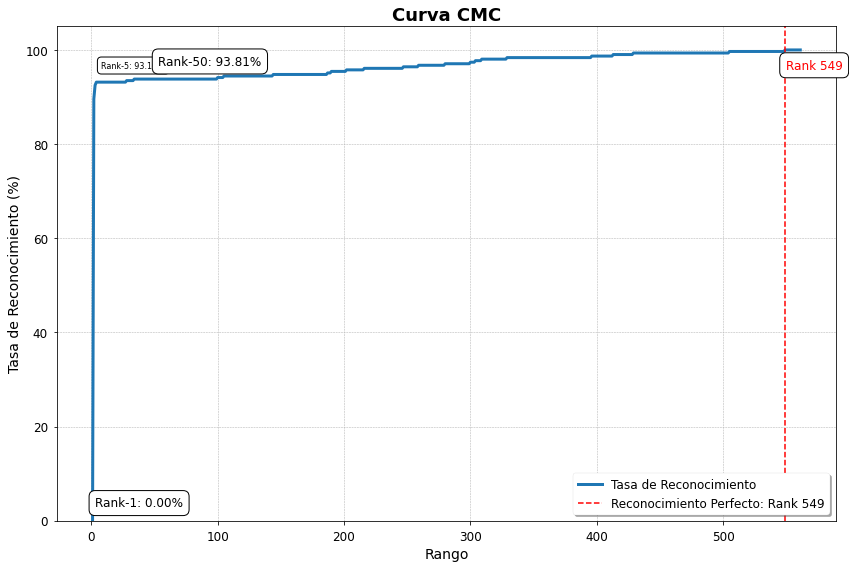

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_cmc(score_matrix, image_to_id):
    probes = score_matrix.index.tolist()
    ranks = []
    for probe_image in probes:
        if probe_image not in image_to_id.index:
            continue

        probe_id = image_to_id.loc[probe_image]
        scores_for_probe = score_matrix.loc[probe_image].sort_values(ascending=False)

        found_match = False
        for rank, (image, score) in enumerate(scores_for_probe.items()):
            if image == probe_image:
                continue

            if image_to_id.loc[image] == probe_id:
                ranks.append(rank + 1)
                found_match = True
                break

        if not found_match:
            continue

    if not ranks:
        return None
    max_rank = len(probes)
    cmc_values = np.zeros(max_rank)

    for i in range(1, max_rank + 1):
        cmc_values[i-1] = np.sum(np.array(ranks) <= i) / len(ranks)
    return cmc_values

# Asumiendo que 'score_matrix' y 'image_to_id' ya están definidos
cmc_values = compute_cmc(score_matrix, image_to_id)

if cmc_values is not None:
    perfect_recognition_index = np.where(cmc_values >= 1.0)[0]
    perfect_rank = perfect_recognition_index[0] + 1 if perfect_recognition_index.size > 0 else None

    # Usar un tamaño de figura más grande para mayor claridad
    fig, ax = plt.subplots(figsize=(12, 8))

    # Graficar la curva con una línea más gruesa y marcadores más grandes
    ax.plot(
        range(1, len(cmc_values) + 1),
        cmc_values * 100,
        #marker='o',
        linestyle='-',
        color='#1f77b4',
        linewidth=3,
        markersize=8,
        label='Tasa de Reconocimiento'
    )

    rank1_rate = cmc_values[0] * 100
    #ax.annotate(
    #    f'Rank-1: {rank1_rate:.2f}%',
    #    xy=(1, rank1_rate),
    #    xytext=(1.5, rank1_rate + 5),
    #    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
    #    fontsize=14,
    #    color='black'
    #)

    ax.text(
        3, # Posición X
        rank1_rate+3,  # Posición Y
        f"Rank-1: {rank1_rate:.2f}%",
        fontsize=12,
        bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1)
    )

    if len(cmc_values) > 4:
        rank5_rate = cmc_values[4] * 100
        #ax.annotate(
        #    f'Rank-5: {rank5_rate:.2f}%',
        #    xy=(5, rank5_rate),
        #    xytext=(5.5, rank5_rate + 5),
        #    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
        #    fontsize=14,
        #    color='black'
        #)

        ax.text(
            8, # Posición X
            rank5_rate+3,  # Posición Y
            f"Rank-5: {rank5_rate:.2f}%",
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1)
        )

    if len(cmc_values) > 49:
        rank50_rate = cmc_values[49] * 100
        #ax.annotate(
        #    f'Rank-50: {rank50_rate:.2f}%',
        #    xy=(50, rank50_rate),
        #    xytext=(5.5, rank50_rate + 5),
        #    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
        #    fontsize=14,
        #    color='black'
        #)

        ax.text(
            53, # Posición X
            rank50_rate+3,  # Posición Y
            f"Rank-50: {rank50_rate:.2f}%",
            fontsize=12,
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1)
        )

    if perfect_rank:
        ax.axvline(
            x=perfect_rank,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label=f'Reconocimiento Perfecto: Rank {perfect_rank}'
        )
        ax.text(
            perfect_rank + 0.5, 96,
            f'Rank {perfect_rank}',
            color='red',
            fontsize=12,
            ha='left',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1)
        )


    ax.set_title('Curva CMC', fontsize=18, fontweight='bold')
    ax.set_xlabel('Rango', fontsize=14)
    ax.set_ylabel('Tasa de Reconocimiento (%)', fontsize=14)
    #ax.set_xlim(0.5, 20)
    ax.set_ylim(0, 105)
    #ax.set_xticks(np.arange(0, 21, 2))
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.legend(loc='lower right', frameon=True, fancybox=True, shadow=True, fontsize='12')

    fig.tight_layout()

    # Guardar la figura en formato EPS (vectorial)
    plt.savefig('curva_cmc.png', format='png')
    plt.show()

In [61]:
import matplotlib.pyplot as plt
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn', 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark', 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep', 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper', 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk', 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid', 'tableau-colorblind10']
